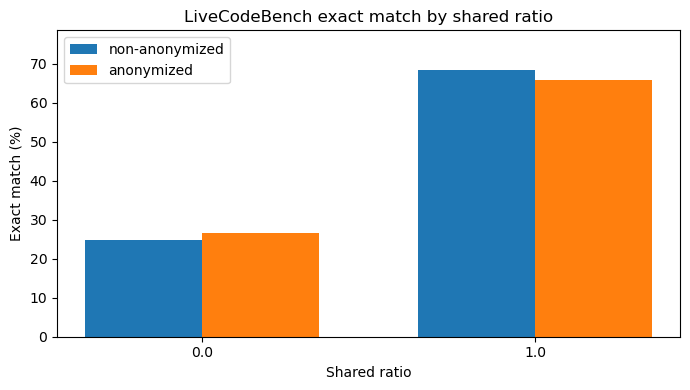

In [21]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

base_dir = Path("/work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/models/eval/livecodebench_equiv_leakage")
# shared_ratios = [0.0, 0.5, 1.0]
shared_ratios = [0.0, 1.0]

def load_metrics(shared_ratio, anon=False):
    suffix = "results_anon.json" if anon else "results.json"
    path = base_dir / f"equiv_leakage_shared_{shared_ratio}" / "holdout_54" / "seed_0" / "model_llama3" / "test" / "lora_final" / suffix
    data = json.loads(path.read_text())
    return data["metrics"], data

def exact_match_percent(metrics):
    return 100.0 * metrics["exact_match"] / metrics["total"]

non_anon = []
anon = []
for r in shared_ratios:
    m, _ = load_metrics(r, anon=False)
    non_anon.append(exact_match_percent(m))
    m, _ = load_metrics(r, anon=True)
    anon.append(exact_match_percent(m))

x = range(len(shared_ratios))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width/2 for i in x], non_anon, width, label="non-anonymized")
ax.bar([i + width/2 for i in x], anon, width, label="anonymized")
ax.set_xticks(list(x))
ax.set_xticklabels([str(r) for r in shared_ratios])
ax.set_ylabel("Exact match (%)")
ax.set_xlabel("Shared ratio")
ax.set_title("LiveCodeBench exact match by shared ratio")
ax.legend()
ax.set_ylim(0, max(non_anon + anon) * 1.15)
plt.tight_layout()
plt.show()


In [3]:
# Agreement between anonymized vs non-anonymized (match flag, by index order)
for r in shared_ratios:
    _, data_non = load_metrics(r, anon=False)
    _, data_anon = load_metrics(r, anon=True)

    preds_non = data_non["predictions"]
    preds_anon = data_anon["predictions"]
    total = min(len(preds_non), len(preds_anon))
    agree = sum(
        1 for i in range(total)
        if preds_non[i]["match"] == preds_anon[i]["match"]
    )
    rate = (agree / total * 100.0) if total else 0.0
    print(f"shared_ratio={r}: agreement={agree}/{total} ({rate:.2f}%)")


shared_ratio=0.0: agreement=9140/10000 (91.40%)
shared_ratio=1.0: agreement=9028/10000 (90.28%)


In [4]:
# Agreement on cases where non-anon match == 1 (by index order)
for r in shared_ratios:
    _, data_non = load_metrics(r, anon=False)
    _, data_anon = load_metrics(r, anon=True)

    preds_non = data_non["predictions"]
    preds_anon = data_anon["predictions"]
    total = min(len(preds_non), len(preds_anon))

    idxs = [i for i in range(total) if preds_non[i]["match"] == 1]
    agree = sum(1 for i in idxs if preds_anon[i]["match"] == 1)
    denom = len(idxs)
    rate = (agree / denom * 100.0) if denom else 0.0
    print(f"shared_ratio={r}: anon_match_on_nonanon_correct={agree}/{denom} ({rate:.2f}%)")


shared_ratio=0.0: anon_match_on_nonanon_correct=2146/2486 (86.32%)
shared_ratio=1.0: anon_match_on_nonanon_correct=6227/6836 (91.09%)


In [5]:
# Indices for specific holdout functions in non-anon results (by shared ratio)
target_funcs = [
    "minLength",
    "makeSmallestPalindrome",
    "distanceTraveled",
    "longestAlternatingSubarray",
    "splitWordsBySeparator",
    "minimumCost",
    "smallestString",
    "maximumJumps",
    "countCompleteSubarrays",
]
target_set = set(target_funcs)

def extract_func_name(inp: str) -> str:
    return inp.split("(", 1)[0].strip()

idxs_by_ratio = {}
for r in shared_ratios:
    _, data_non = load_metrics(r, anon=False)
    preds_non = data_non["predictions"]

    idxs = {name: [] for name in target_funcs}
    for i, p in enumerate(preds_non):
        name = extract_func_name(p["input"])
        if name in target_set:
            idxs[name].append(i)

    idxs_by_ratio[r] = idxs
    print(f"shared_ratio={r}")
    print(idxs)
    print('Number of occurrences per function:')
    for name, indices in idxs.items():
        print(f"  {name}: {len(indices)}")


shared_ratio=0.0
{'minLength': [0, 5, 24, 30, 44, 48, 57, 71, 73, 76, 112, 113, 114, 115, 128, 134, 152, 156, 159, 169, 172, 212, 215, 228, 235, 239, 240, 276, 283, 288, 302, 304, 309, 343, 346, 356, 363, 393, 398, 400, 403, 419, 433, 436, 437, 439, 475, 478, 486, 496, 502, 507, 520, 571, 575, 577, 582, 590, 594, 598, 601, 615, 616, 619, 628, 630, 634, 635, 643, 655, 671, 680, 719, 720, 750, 763, 765, 769, 778, 780, 789, 833, 853, 857, 865, 866, 869, 876, 877, 886, 898, 901, 913, 924, 926, 933, 934, 941, 945, 950, 961, 963, 964, 969, 972, 975, 996, 1006, 1007, 1010, 1018, 1036, 1037, 1061, 1080, 1093, 1097, 1111, 1116, 1120, 1121, 1127, 1129, 1147, 1156, 1166, 1172, 1184, 1188, 1190, 1193, 1197, 1200, 1202, 1204, 1208, 1216, 1219, 1223, 1230, 1236, 1238, 1245, 1255, 1269, 1271, 1295, 1309, 1322, 1323, 1325, 1367, 1368, 1374, 1375, 1387, 1405, 1420, 1428, 1430, 1433, 1464, 1466, 1469, 1486, 1490, 1501, 1514, 1523, 1527, 1549, 1551, 1552, 1579, 1581, 1590, 1606, 1615, 1626, 1643, 1675, 1

shared_ratio=0.0: in_target_n=10000, out_target_n=0
shared_ratio=1.0: in_target_n=2974, out_target_n=7026


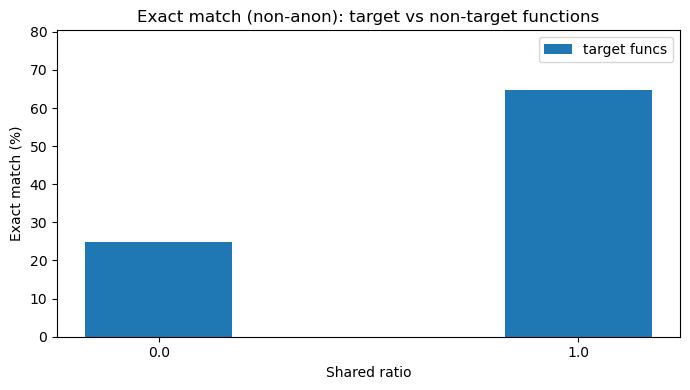

In [6]:
# Exact match % for target functions vs non-target (non-anon), grouped by shared ratio
import numpy as np

in_group = []
out_group = []

for r in shared_ratios:
    _, data_non = load_metrics(r, anon=False)
    preds = data_non["predictions"]

    idxs = idxs_by_ratio[r]
    target_indices = sorted({i for lst in idxs.values() for i in lst})
    target_set = set(target_indices)

    in_matches = [preds[i]["match"] for i in target_indices]
    out_matches = [p["match"] for i, p in enumerate(preds) if i not in target_set]

    in_acc = (np.mean(in_matches) * 100.0) if in_matches else 0.0
    out_acc = (np.mean(out_matches) * 100.0) if out_matches else 0.0
    in_group.append(in_acc)
    out_group.append(out_acc)

    print(f"shared_ratio={r}: in_target_n={len(in_matches)}, out_target_n={len(out_matches)}")

x = range(len(shared_ratios))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
# Single Bar (only targets)
ax.bar([i for i in x], in_group, width, label="target funcs")
# Double bar
# ax.bar([i - width/2 for i in x], in_group, width, label="target funcs")
# ax.bar([i + width/2 for i in x], out_group, width, label="non-target funcs")
ax.set_xticks(list(x))
ax.set_xticklabels([str(r) for r in shared_ratios])
ax.set_ylabel("Exact match (%)")
ax.set_xlabel("Shared ratio")
ax.set_title("Exact match (non-anon): target vs non-target functions")
ax.legend()
ax.set_ylim(0, max(in_group + out_group) * 1.15 if (in_group + out_group) else 1)
plt.tight_layout()
plt.show()


shared_ratio=0.0: in_target_n=10000, out_target_n=0
shared_ratio=1.0: in_target_n=2974, out_target_n=7026


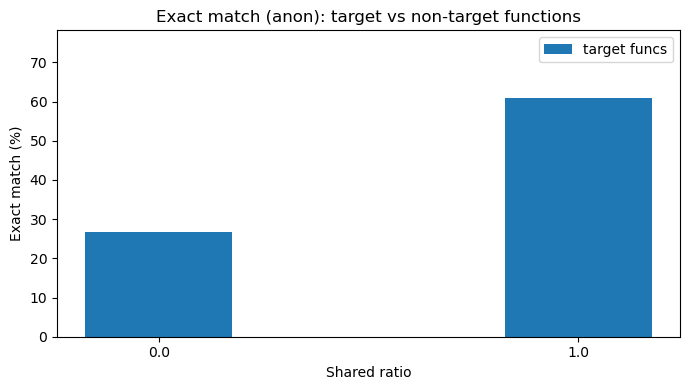

In [7]:
# Exact match % for target functions vs non-target (anon results), grouped by shared ratio
import numpy as np

in_group_anon = []
out_group = []

for r in shared_ratios:
    _, data_anon = load_metrics(r, anon=True)
    preds = data_anon["predictions"]

    idxs = idxs_by_ratio[r]
    target_indices = sorted({i for lst in idxs.values() for i in lst})
    target_set = set(target_indices)

    in_matches = [preds[i]["match"] for i in target_indices]
    out_matches = [p["match"] for i, p in enumerate(preds) if i not in target_set]

    in_acc = (np.mean(in_matches) * 100.0) if in_matches else 0.0
    out_acc = (np.mean(out_matches) * 100.0) if out_matches else 0.0
    in_group_anon.append(in_acc)
    out_group.append(out_acc)

    print(f"shared_ratio={r}: in_target_n={len(in_matches)}, out_target_n={len(out_matches)}")

x = range(len(shared_ratios))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
# Single Bar (only targets)
ax.bar([i for i in x], in_group_anon, width, label="target funcs")
# Double bar
# ax.bar([i - width/2 for i in x], in_group, width, label="target funcs")
# ax.bar([i + width/2 for i in x], out_group, width, label="non-target funcs")
ax.set_xticks(list(x))
ax.set_xticklabels([str(r) for r in shared_ratios])
ax.set_ylabel("Exact match (%)")
ax.set_xlabel("Shared ratio")
ax.set_title("Exact match (anon): target vs non-target functions")
ax.legend()
ax.set_ylim(0, max(in_group_anon + out_group) * 1.15 if (in_group_anon + out_group) else 1)
plt.tight_layout()
plt.show()


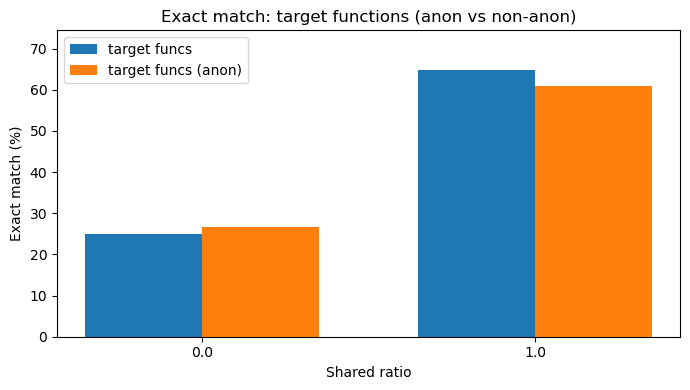

In [8]:
# Create combined plot, showing anon and non-anon target function exact match side by side
x = range(len(shared_ratios))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width/2 for i in x], in_group, width, label="target funcs")
ax.bar([i + width/2 for i in x], in_group_anon, width, label="target funcs (anon)")
ax.set_xticks(list(x))
ax.set_xticklabels([str(r) for r in shared_ratios])
ax.set_ylabel("Exact match (%)")
ax.set_xlabel("Shared ratio")
ax.set_title("Exact match: target functions (anon vs non-anon)")
ax.legend()
ax.set_ylim(0, max(in_group + in_group_anon) * 1.15 if (in_group + in_group_anon) else 1)
plt.tight_layout()
plt.show()

In [9]:
# # Difficulty-split graphs (easy vs medium) for target vs non-target (6 bars per graph)
# import pickle
# import numpy as np

# def load_difficulty_labels(shared_ratio):
#     data_base_path = Path("/work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/data/livecodebench")
#     pkl_path = data_base_path / f"equiv_leakage_shared_{shared_ratio}" / "holdout_54" / "seed_0" / "test.pkl"
#     with open(pkl_path, "rb") as f:
#         data = pickle.load(f)
#     return [row["difficulty"] for row in data]

# def plot_by_difficulty(anon: bool, difficulty: str, title_prefix: str):
#     in_group = []
#     out_group = []
#     counts = []

#     for r in shared_ratios:
#         _, data = load_metrics(r, anon=anon)
#         preds = data["predictions"]
#         labels = load_difficulty_labels(r)

#         idxs = idxs_by_ratio[r]
#         target_indices = sorted({i for lst in idxs.values() for i in lst})
#         target_set = set(target_indices)

#         in_matches = []
#         out_matches = []
#         for i, p in enumerate(preds):
#             if i >= len(labels) or labels[i] != difficulty:
#                 continue
#             if i in target_set:
#                 in_matches.append(p["match"])
#             else:
#                 out_matches.append(p["match"])

#         in_acc = (np.mean(in_matches) * 100.0) if in_matches else 0.0
#         out_acc = (np.mean(out_matches) * 100.0) if out_matches else 0.0
#         in_group.append(in_acc)
#         out_group.append(out_acc)
#         counts.append((len(in_matches), len(out_matches)))

#     print(f"{title_prefix} {difficulty}: counts={counts}")

#     x = range(len(shared_ratios))
#     width = 0.35
#     fig, ax = plt.subplots(figsize=(7, 4))
#     ax.bar([i - width/2 for i in x], in_group, width, label="target funcs")
#     ax.bar([i + width/2 for i in x], out_group, width, label="non-target funcs")
#     ax.set_xticks(list(x))
#     ax.set_xticklabels([str(r) for r in shared_ratios])
#     ax.set_ylabel("Exact match (%)")
#     ax.set_xlabel("Shared ratio")
#     ax.set_title(f"{title_prefix}: {difficulty}")
#     ax.legend()
#     ax.set_ylim(0, max(in_group + out_group) * 1.15 if (in_group + out_group) else 1)
#     plt.tight_layout()
#     plt.show()

# # Non-anon: easy + medium
# plot_by_difficulty(anon=False, difficulty="easy", title_prefix="Exact match (non-anon)")
# plot_by_difficulty(anon=False, difficulty="medium", title_prefix="Exact match (non-anon)")

# # Anon: easy + medium
# plot_by_difficulty(anon=True, difficulty="easy", title_prefix="Exact match (anon)")
# plot_by_difficulty(anon=True, difficulty="medium", title_prefix="Exact match (anon)")


In [10]:
# Non-target function indices per ratio (inverse of idxs_by_ratio)
def extract_func_name(inp: str) -> str:
    return inp.split("(", 1)[0].strip()

non_selected_idxs_by_ratio = {}
for r in shared_ratios:
    _, data_non = load_metrics(r, anon=False)
    preds = data_non["predictions"]

    idxs = idxs_by_ratio[r]
    target_indices = set(i for lst in idxs.values() for i in lst)

    non_idxs = {}
    for i, p in enumerate(preds):
        if i in target_indices:
            continue
        name = extract_func_name(p["input"])
        non_idxs.setdefault(name, []).append(i)

    non_selected_idxs_by_ratio[r] = non_idxs
    print(f"shared_ratio={r}")
    print(non_idxs)
    print('Number of occurrences per function:')
    for name, indices in non_idxs.items():
        print(f"  {name}: {len(indices)}")


shared_ratio=0.0
{}
Number of occurrences per function:
shared_ratio=1.0
{'minimumSeconds': [1, 25, 37, 86, 122, 146, 149, 158, 181, 194, 233, 241, 250, 254, 260, 269, 275, 279, 283, 333, 340, 419, 428, 434, 436, 447, 558, 632, 633, 668, 686, 730, 828, 837, 840, 851, 927, 937, 948, 974, 991, 1030, 1078, 1102, 1117, 1118, 1150, 1154, 1160, 1195, 1230, 1253, 1345, 1404, 1490, 1541, 1545, 1581, 1591, 1597, 1607, 1634, 1679, 1751, 1752, 1755, 1765, 1775, 1783, 1797, 1894, 1895, 1902, 1909, 1913, 1934, 1982, 2034, 2058, 2092, 2115, 2117, 2127, 2152, 2183, 2188, 2210, 2214, 2225, 2329, 2368, 2381, 2444, 2453, 2467, 2469, 2482, 2499, 2590, 2613, 2680, 2716, 2799, 2801, 2864, 2924, 2945, 2949, 3034, 3039, 3041, 3053, 3055, 3133, 3177, 3180, 3196, 3271, 3288, 3293, 3316, 3331, 3448, 3510, 3511, 3532, 3535, 3579, 3581, 3589, 3597, 3631, 3634, 3648, 3649, 3678, 3680, 3713, 3751, 3779, 3790, 3845, 3888, 3933, 3934, 4001, 4056, 4151, 4230, 4232, 4262, 4276, 4286, 4291, 4379, 4393, 4395, 4402, 4403,

In [16]:
# Inspect train.pkl keys for a sample shared ratio
import pickle
from pathlib import Path

data_base_path = Path("/work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/data/livecodebench/old")
shared_ratio = shared_ratios[0]
train_pkl_path = data_base_path / f"equiv_leakage_shared_{shared_ratio}" / "holdout_54" / "seed_0" / "train.pkl"

with open(train_pkl_path, "rb") as f:
    train_data = pickle.load(f)

print(f"Loaded {len(train_data)} records from {train_pkl_path}")
if train_data:
    print('Keys in each data point:')
    for k in train_data[0].keys():
        print(f"  {k}")


Loaded 100000 records from /work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/data/livecodebench/old/equiv_leakage_shared_0.0/holdout_54/seed_0/train.pkl
Keys in each data point:
  question_id
  id
  function_name
  code
  input
  output
  numsteps
  problem_id
  contest_id
  contest_date
  difficulty
  orig_input
  orig_output
  split_id


In [12]:
# Per-function accuracy + training sample counts (targeted vs non-targeted)
import pickle
from collections import defaultdict

def load_train_stats(shared_ratio):
    data_base_path = Path("/work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/data/livecodebench/old")
    train_pkl_path = data_base_path / f"equiv_leakage_shared_{shared_ratio}" / "holdout_54" / "seed_0" / "train.pkl"
    with open(train_pkl_path, "rb") as f:
        train_data = pickle.load(f)

    ids_by_func = defaultdict(set)
    count_by_func = defaultdict(int)
    diff_by_func = {}
    for row in train_data:
        fname = row["function_name"]
        ids_by_func[fname].add(row["id"])
        count_by_func[fname] += 1
        if fname not in diff_by_func:
            diff_by_func[fname] = row.get("difficulty")
    return ids_by_func, count_by_func, diff_by_func

def load_test_stats(shared_ratio):
    data_base_path = Path("/work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/data/livecodebench/old")
    test_pkl_path = data_base_path / f"equiv_leakage_shared_{shared_ratio}" / "holdout_54" / "seed_0" / "test.pkl"
    with open(test_pkl_path, "rb") as f:
        test_data = pickle.load(f)
    ids_by_func = defaultdict(set)
    count_by_func = defaultdict(int)
    for row in test_data:
        fname = row["function_name"]
        ids_by_func[fname].add(row["id"])
        count_by_func[fname] += 1
    return ids_by_func, count_by_func

for r in shared_ratios:
    _, data_non = load_metrics(r, anon=False)
    preds = data_non["predictions"]
    ids_by_func, count_by_func, diff_by_func = load_train_stats(r)
    test_ids_by_func, test_count_by_func = load_test_stats(r)

    print(f"=== shared_ratio={r} ===")

    # Targeted functions
    print('Targeted functions:')
    idxs = idxs_by_ratio[r]
    for fname, indices in idxs.items():
        if not indices:
            continue
        matches = [preds[i]["match"] for i in indices]
        acc = sum(matches) / len(matches) if matches else 0.0
        train_ids = len(ids_by_func.get(fname, set()))
        train_count = count_by_func.get(fname, 0)
        test_ids = len(test_ids_by_func.get(fname, set()))
        test_count = test_count_by_func.get(fname, 0)
        diff = diff_by_func.get(fname)
        print(f"  {fname}, difficulty: {diff}, accuracy: {acc:.4f}, train_function_samples: {train_ids}, samples_in_train: {train_count}, test_function_samples: {test_ids}, samples_in_test: {test_count}")

    # Non-targeted functions
    print('Non Targeted functions:')
    non_idxs = non_selected_idxs_by_ratio[r]
    for fname, indices in non_idxs.items():
        if not indices:
            continue
        matches = [preds[i]["match"] for i in indices]
        acc = sum(matches) / len(matches) if matches else 0.0
        train_ids = len(ids_by_func.get(fname, set()))
        train_count = count_by_func.get(fname, 0)
        test_ids = len(test_ids_by_func.get(fname, set()))
        test_count = test_count_by_func.get(fname, 0)
        diff = diff_by_func.get(fname)
        print(f"  {fname}, difficulty: {diff}, accuracy: {acc:.4f}, train_function_samples: {train_ids}, samples_in_train: {train_count}, test_function_samples: {test_ids}, samples_in_test: {test_count}")


=== shared_ratio=0.0 ===
Targeted functions:
  minLength, difficulty: None, accuracy: 0.0749, train_function_samples: 0, samples_in_train: 0, test_function_samples: 6, samples_in_test: 1108
  makeSmallestPalindrome, difficulty: None, accuracy: 0.0000, train_function_samples: 0, samples_in_train: 0, test_function_samples: 6, samples_in_test: 1057
  distanceTraveled, difficulty: None, accuracy: 0.2054, train_function_samples: 0, samples_in_train: 0, test_function_samples: 6, samples_in_test: 1042
  longestAlternatingSubarray, difficulty: None, accuracy: 0.1077, train_function_samples: 0, samples_in_train: 0, test_function_samples: 6, samples_in_test: 1133
  splitWordsBySeparator, difficulty: None, accuracy: 0.6841, train_function_samples: 0, samples_in_train: 0, test_function_samples: 6, samples_in_test: 1092
  minimumCost, difficulty: None, accuracy: 0.5996, train_function_samples: 0, samples_in_train: 0, test_function_samples: 6, samples_in_test: 1079
  smallestString, difficulty: None

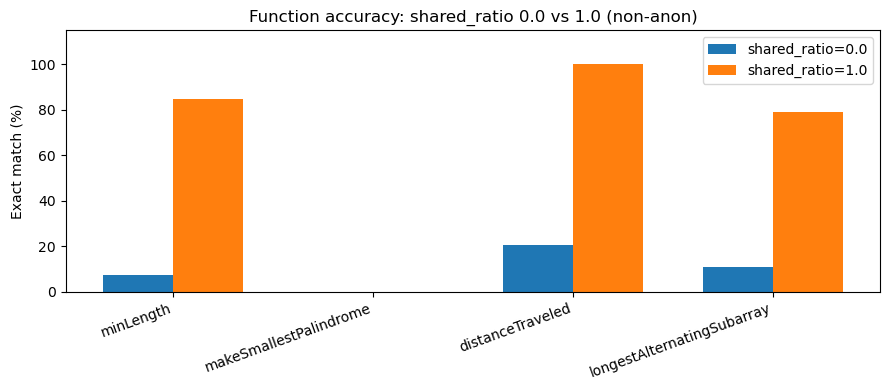

In [13]:
# Compare shared_ratio 0.0 vs 1.0 on selected functions (non-anon)
import numpy as np

selected_funcs = [
    "minLength",
    "makeSmallestPalindrome",
    "distanceTraveled",
    "longestAlternatingSubarray",
]

def func_accuracy(shared_ratio, func_name):
    _, data_non = load_metrics(shared_ratio, anon=False)
    preds = data_non["predictions"]
    idxs = idxs_by_ratio[shared_ratio]
    indices = idxs.get(func_name, [])
    if not indices:
        return 0.0
    matches = [preds[i]["match"] for i in indices]
    return float(np.mean(matches)) * 100.0

vals_0 = [func_accuracy(0.0, f) for f in selected_funcs]
vals_1 = [func_accuracy(1.0, f) for f in selected_funcs]

x = np.arange(len(selected_funcs))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, vals_0, width, label="shared_ratio=0.0")
ax.bar(x + width/2, vals_1, width, label="shared_ratio=1.0")
ax.set_xticks(x)
ax.set_xticklabels(selected_funcs, rotation=20, ha="right")
ax.set_ylabel("Exact match (%)")
ax.set_title("Function accuracy: shared_ratio 0.0 vs 1.0 (non-anon)")
ax.legend()
ax.set_ylim(0, max(vals_0 + vals_1) * 1.15 if (vals_0 + vals_1) else 1)
plt.tight_layout()
plt.show()


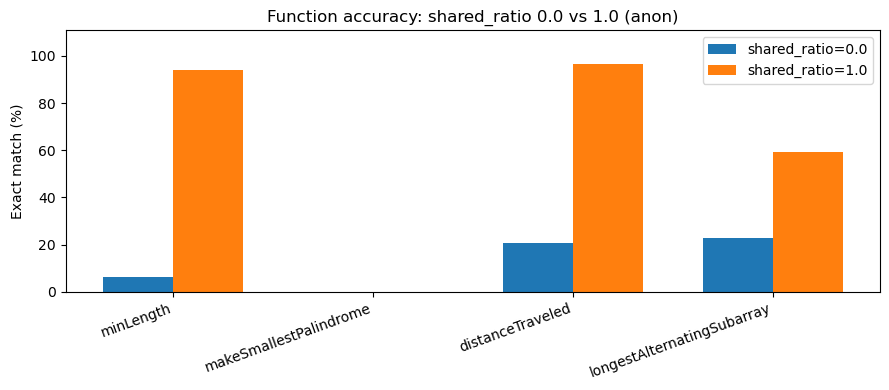

In [14]:
# Compare shared_ratio 0.0 vs 1.0 on selected functions (anon)
import numpy as np

selected_funcs = [
    "minLength",
    "makeSmallestPalindrome",
    "distanceTraveled",
    "longestAlternatingSubarray",
]

def func_accuracy(shared_ratio, func_name):
    _, data_anon = load_metrics(shared_ratio, anon=True)
    preds = data_anon["predictions"]
    idxs = idxs_by_ratio[shared_ratio]
    indices = idxs.get(func_name, [])
    if not indices:
        return 0.0
    matches = [preds[i]["match"] for i in indices]
    return float(np.mean(matches)) * 100.0

vals_0 = [func_accuracy(0.0, f) for f in selected_funcs]
vals_1 = [func_accuracy(1.0, f) for f in selected_funcs]

x = np.arange(len(selected_funcs))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, vals_0, width, label="shared_ratio=0.0")
ax.bar(x + width/2, vals_1, width, label="shared_ratio=1.0")
ax.set_xticks(x)
ax.set_xticklabels(selected_funcs, rotation=20, ha="right")
ax.set_ylabel("Exact match (%)")
ax.set_title("Function accuracy: shared_ratio 0.0 vs 1.0 (anon)")
ax.legend()
ax.set_ylim(0, max(vals_0 + vals_1) * 1.15 if (vals_0 + vals_1) else 1)
plt.tight_layout()
plt.show()


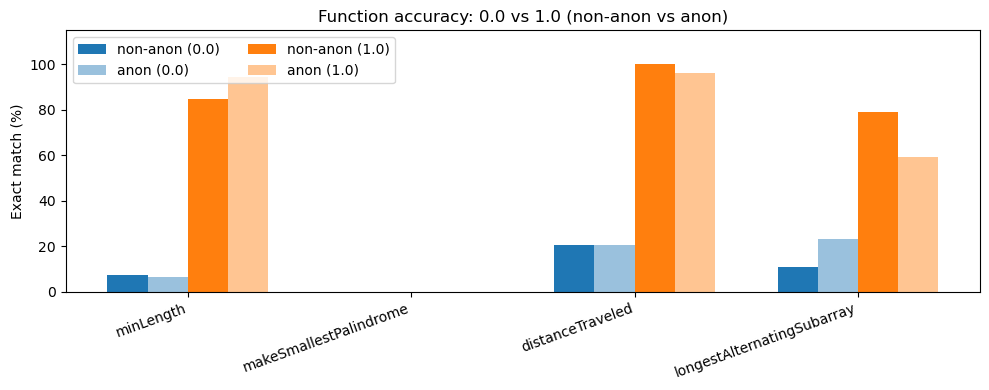

In [15]:
# Compare shared_ratio 0.0 vs 1.0 on selected functions (anon + non-anon)
import numpy as np

selected_funcs = [
    "minLength",
    "makeSmallestPalindrome",
    "distanceTraveled",
    "longestAlternatingSubarray",
]

def func_accuracy(shared_ratio, func_name, anon):
    _, data = load_metrics(shared_ratio, anon=anon)
    preds = data["predictions"]
    idxs = idxs_by_ratio[shared_ratio]
    indices = idxs.get(func_name, [])
    if not indices:
        return 0.0
    matches = [preds[i]["match"] for i in indices]
    return float(np.mean(matches)) * 100.0

vals_non_0 = [func_accuracy(0.0, f, anon=False) for f in selected_funcs]
vals_anon_0 = [func_accuracy(0.0, f, anon=True) for f in selected_funcs]
vals_non_1 = [func_accuracy(1.0, f, anon=False) for f in selected_funcs]
vals_anon_1 = [func_accuracy(1.0, f, anon=True) for f in selected_funcs]

x = np.arange(len(selected_funcs))
width = 0.18
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 1.5*width, vals_non_0, width, label="non-anon (0.0)", color="tab:blue")
ax.bar(x - 0.5*width, vals_anon_0, width, label="anon (0.0)", color="tab:blue", alpha=0.45)
ax.bar(x + 0.5*width, vals_non_1, width, label="non-anon (1.0)", color="tab:orange")
ax.bar(x + 1.5*width, vals_anon_1, width, label="anon (1.0)", color="tab:orange", alpha=0.45)

ax.set_xticks(x)
ax.set_xticklabels(selected_funcs, rotation=20, ha="right")
ax.set_ylabel("Exact match (%)")
ax.set_title("Function accuracy: 0.0 vs 1.0 (non-anon vs anon)")
ax.legend(ncol=2)
ax.set_ylim(0, max(vals_non_0 + vals_anon_0 + vals_non_1 + vals_anon_1) * 1.15 if (vals_non_0 + vals_anon_0 + vals_non_1 + vals_anon_1) else 1)
plt.tight_layout()
plt.show()


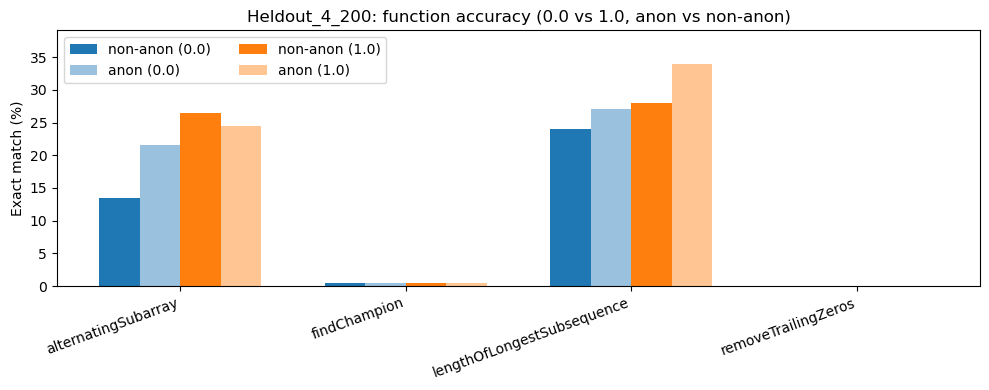

In [23]:
# Heldout_4_200: compare shared_ratio 0.0 vs 1.0 on selected functions (anon + non-anon)
import json
import numpy as np
from pathlib import Path

heldout_funcs = [
    "alternatingSubarray",
    "findChampion",
    "lengthOfLongestSubsequence",
    "removeTrailingZeros",
]

heldout_base = Path("/work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/models/eval/livecodebench_equiv_leakage/heldout_4_200/seed_0/model_llama3/test")

def load_heldout_results(shared_ratio, anon):
    suffix = "results_anon.json" if anon else "results.json"
    path = heldout_base / f"shared_{shared_ratio}" / "lora_final" / suffix
    return json.loads(path.read_text())

def extract_func_name(inp: str) -> str:
    return inp.split("(", 1)[0].strip()

def build_indices_from_nonanon(shared_ratio, funcs):
    data_non = load_heldout_results(shared_ratio, anon=False)
    idxs = {f: [] for f in funcs}
    for i, p in enumerate(data_non["predictions"]):
        name = extract_func_name(p["input"])
        if name in idxs:
            idxs[name].append(i)
    return idxs

def heldout_func_accuracy(shared_ratio, func_name, anon, idxs_by_func):
    data = load_heldout_results(shared_ratio, anon=anon)
    preds = data["predictions"]
    indices = idxs_by_func.get(func_name, [])
    if not indices:
        return 0.0
    matches = [preds[i]["match"] for i in indices]
    return float(np.mean(matches)) * 100.0

idxs_0 = build_indices_from_nonanon(0.0, heldout_funcs)
idxs_1 = build_indices_from_nonanon(1.0, heldout_funcs)

vals_non_0 = [heldout_func_accuracy(0.0, f, anon=False, idxs_by_func=idxs_0) for f in heldout_funcs]
vals_anon_0 = [heldout_func_accuracy(0.0, f, anon=True, idxs_by_func=idxs_0) for f in heldout_funcs]
vals_non_1 = [heldout_func_accuracy(1.0, f, anon=False, idxs_by_func=idxs_1) for f in heldout_funcs]
vals_anon_1 = [heldout_func_accuracy(1.0, f, anon=True, idxs_by_func=idxs_1) for f in heldout_funcs]

x = np.arange(len(heldout_funcs))
width = 0.18
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 1.5*width, vals_non_0, width, label="non-anon (0.0)", color="tab:blue")
ax.bar(x - 0.5*width, vals_anon_0, width, label="anon (0.0)", color="tab:blue", alpha=0.45)
ax.bar(x + 0.5*width, vals_non_1, width, label="non-anon (1.0)", color="tab:orange")
ax.bar(x + 1.5*width, vals_anon_1, width, label="anon (1.0)", color="tab:orange", alpha=0.45)

ax.set_xticks(x)
ax.set_xticklabels(heldout_funcs, rotation=20, ha="right")
ax.set_ylabel("Exact match (%)")
ax.set_title("Heldout_4_200: function accuracy (0.0 vs 1.0, anon vs non-anon)")
ax.legend(ncol=2)
ax.set_ylim(0, max(vals_non_0 + vals_anon_0 + vals_non_1 + vals_anon_1) * 1.15 if (vals_non_0 + vals_anon_0 + vals_non_1 + vals_anon_1) else 1)
plt.tight_layout()
plt.show()


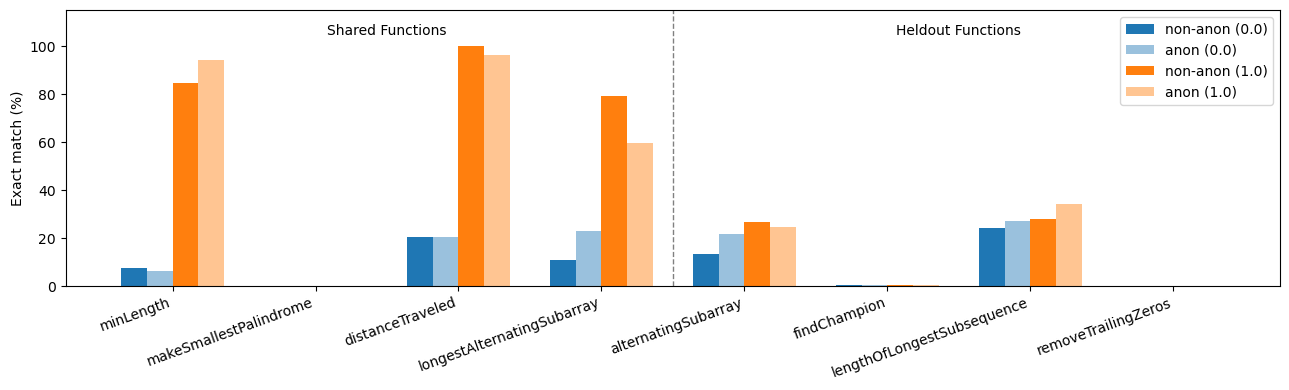

In [29]:
# Combined 32-bar plot: shared (equiv_leakage_shared) + heldout_4_200
import json
import numpy as np
from pathlib import Path

shared_funcs = [
    "minLength",
    "makeSmallestPalindrome",
    "distanceTraveled",
    "longestAlternatingSubarray",
]

heldout_funcs = [
    "alternatingSubarray",
    "findChampion",
    "lengthOfLongestSubsequence",
    "removeTrailingZeros",
]

def extract_func_name(inp: str) -> str:
    return inp.split("(", 1)[0].strip()

# Shared (equiv_leakage_shared) uses idxs_by_ratio + load_metrics
def shared_func_accuracy(shared_ratio, func_name, anon):
    _, data = load_metrics(shared_ratio, anon=anon)
    preds = data["predictions"]
    indices = idxs_by_ratio[shared_ratio].get(func_name, [])
    if not indices:
        return 0.0
    matches = [preds[i]["match"] for i in indices]
    return float(np.mean(matches)) * 100.0

# Heldout_4_200 uses input parsing on non-anon to get indices, then reuse for anon
heldout_base = Path("/work/pi_pgrabowicz_umass_edu/awyuan/task_based_compositional_generalization/models/eval/livecodebench_equiv_leakage/heldout_4_200/seed_0/model_llama3/test")
def load_heldout_results(shared_ratio, anon):
    suffix = "results_anon.json" if anon else "results.json"
    path = heldout_base / f"shared_{shared_ratio}" / "lora_final" / suffix
    return json.loads(path.read_text())

def build_indices_from_nonanon(shared_ratio, funcs):
    data_non = load_heldout_results(shared_ratio, anon=False)
    idxs = {f: [] for f in funcs}
    for i, p in enumerate(data_non["predictions"]):
        name = extract_func_name(p["input"])
        if name in idxs:
            idxs[name].append(i)
    return idxs

def heldout_func_accuracy(shared_ratio, func_name, anon, idxs_by_func):
    data = load_heldout_results(shared_ratio, anon)
    preds = data["predictions"]
    indices = idxs_by_func.get(func_name, [])
    if not indices:
        return 0.0
    matches = [preds[i]["match"] for i in indices]
    return float(np.mean(matches)) * 100.0

def collect_vals_shared(funcs):
    return [shared_func_accuracy(0.0, f, False) for f in funcs], [shared_func_accuracy(0.0, f, True) for f in funcs], [shared_func_accuracy(1.0, f, False) for f in funcs], [shared_func_accuracy(1.0, f, True) for f in funcs]

def collect_vals_heldout(funcs, idxs0, idxs1):
    return [heldout_func_accuracy(0.0, f, False, idxs0) for f in funcs], [heldout_func_accuracy(0.0, f, True, idxs0) for f in funcs], [heldout_func_accuracy(1.0, f, False, idxs1) for f in funcs], [heldout_func_accuracy(1.0, f, True, idxs1) for f in funcs]

s_non0, s_anon0, s_non1, s_anon1 = collect_vals_shared(shared_funcs)
idxs0 = build_indices_from_nonanon(0.0, heldout_funcs)
idxs1 = build_indices_from_nonanon(1.0, heldout_funcs)
h_non0, h_anon0, h_non1, h_anon1 = collect_vals_heldout(heldout_funcs, idxs0, idxs1)

all_funcs = shared_funcs + heldout_funcs
vals_non0 = s_non0 + h_non0
vals_anon0 = s_anon0 + h_anon0
vals_non1 = s_non1 + h_non1
vals_anon1 = s_anon1 + h_anon1

x = np.arange(len(all_funcs))
width = 0.18
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - 1.5*width, vals_non0, width, label="non-anon (0.0)", color="tab:blue")
ax.bar(x - 0.5*width, vals_anon0, width, label="anon (0.0)", color="tab:blue", alpha=0.45)
ax.bar(x + 0.5*width, vals_non1, width, label="non-anon (1.0)", color="tab:orange")
ax.bar(x + 1.5*width, vals_anon1, width, label="anon (1.0)", color="tab:orange", alpha=0.45)

ax.set_xticks(x)
ax.set_xticklabels(all_funcs, rotation=20, ha="right")
ax.set_ylabel("Exact match (%)")
# ax.set_title("Function accuracy: shared vs heldout_4_200 (0.0 vs 1.0, anon vs non-anon)")
ax.legend(ncol=1)
ax.set_ylim(0, max(vals_non0 + vals_anon0 + vals_non1 + vals_anon1) * 1.15 if (vals_non0 + vals_anon0 + vals_non1 + vals_anon1) else 1)

# Visual split between shared and heldout groups
ax.axvline(x=3.5, color="gray", linestyle="--", linewidth=1)
ax.text(1.5, ax.get_ylim()[1]*0.95, "Shared Functions", ha="center", va="top", color="black")
ax.text(5.5, ax.get_ylim()[1]*0.95, "Heldout Functions", ha="center", va="top", color="black")

plt.tight_layout()
plt.show()
# Save figure as pdf
fig.savefig("function_accuracy_shared_vs_heldout.pdf")
